# Wizualizacje końcowe

## Cel tego notebooka

Generujemy wykresy do bezpośredniego użycia w pracy magisterskiej.
Wszystkie wykresy są zapisywane jako PNG w wysokiej rozdzielczości (dpi=150).

Wykresy pokrywają:
1. Porównanie modeli (RMSE, MAE, R²)
2. Rzeczywiste vs przewidywane oceny
3. Analiza reszt
4. Współczynniki regresji — ważność cech
5. Krzywa ROC modelu logistycznego
6. Macierz korelacji cech

In [1]:
import os
os.chdir(os.path.expanduser('~/magisterka'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    roc_curve, auc
)

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.bbox'] = 'tight'

FEATURE_COLS  = joblib.load('backend/model/feature_cols.pkl')
lr            = joblib.load('backend/model/linear_model.pkl')
ridge         = joblib.load('backend/model/ridge_model.pkl')
lasso         = joblib.load('backend/model/lasso_model.pkl')
log_reg       = joblib.load('backend/model/logistic_model.pkl')

X_train = np.load('data/X_train.npy')
X_test  = np.load('data/X_test.npy')
y_train = np.load('data/y_train.npy')
y_test  = np.load('data/y_test.npy')

y_pred_lr     = lr.predict(X_test)
y_pred_ridge  = ridge.predict(X_test)
y_pred_lasso  = lasso.predict(X_test)

y_test_binary       = (y_test >= 4).astype(int)
y_pred_log_proba    = log_reg.predict_proba(X_test)[:, 1]

print("Wszystko wczytane.")

Wszystko wczytane.


## Wykres 1 — Porównanie modeli regresji

Tabela i wykres słupkowy zestawiający Baseline, Linear Regression,
Ridge i Lasso według metryk RMSE, MAE i R².

,RMSE,MAE,R²
Baseline,1.2163,0.9733,0.0000
Linear Regression,0.9120,0.7177,0.3520
Ridge,0.9120,0.7177,0.3520
Lasso,0.9129,0.7192,0.3508


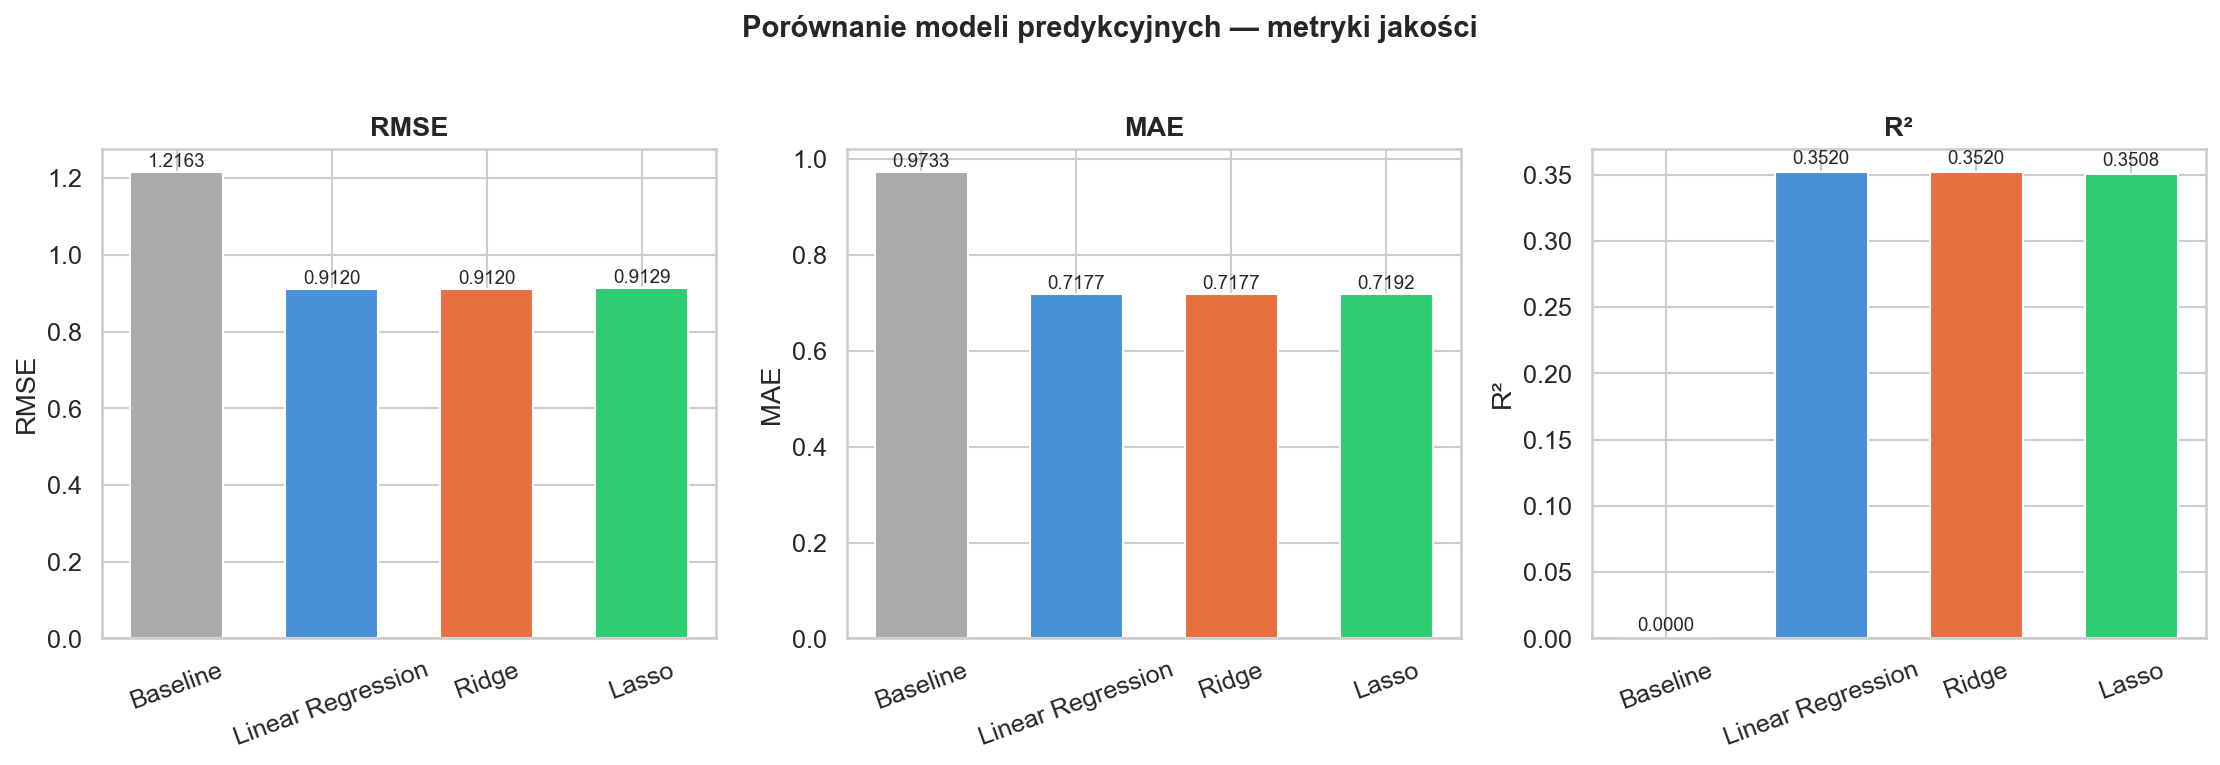

Zapisano: fig1_model_comparison.png


In [2]:
baseline_pred = np.full_like(y_test, y_train.mean())

metrics = {
    'Baseline':           [np.sqrt(mean_squared_error(y_test, baseline_pred)),
                           mean_absolute_error(y_test, baseline_pred), 0.0],
    'Linear Regression':  [np.sqrt(mean_squared_error(y_test, y_pred_lr)),
                           mean_absolute_error(y_test, y_pred_lr),
                           r2_score(y_test, y_pred_lr)],
    'Ridge':              [np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
                           mean_absolute_error(y_test, y_pred_ridge),
                           r2_score(y_test, y_pred_ridge)],
    'Lasso':              [np.sqrt(mean_squared_error(y_test, y_pred_lasso)),
                           mean_absolute_error(y_test, y_pred_lasso),
                           r2_score(y_test, y_pred_lasso)],
}

results = pd.DataFrame(metrics, index=['RMSE', 'MAE', 'R²']).T.round(4)
display(results)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#aaaaaa', '#4a90d9', '#e87040', '#2ecc71']

for ax, metric in zip(axes, ['RMSE', 'MAE', 'R²']):
    bars = ax.bar(results.index, results[metric], color=colors, edgecolor='white', width=0.6)
    ax.set_title(f'{metric}', fontweight='bold', fontsize=13)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, results[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.003,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Porównanie modeli predykcyjnych — metryki jakości',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('notebooks/fig1_model_comparison.png')
plt.show()
print("Zapisano: fig1_model_comparison.png")

## Wykres 2 — Rzeczywiste vs przewidywane oceny

Scatter plot dla wszystkich trzech modeli regresji.
Czerwona linia przerywana = idealne przewidywanie.
Próbka 3000 punktów dla czytelności.

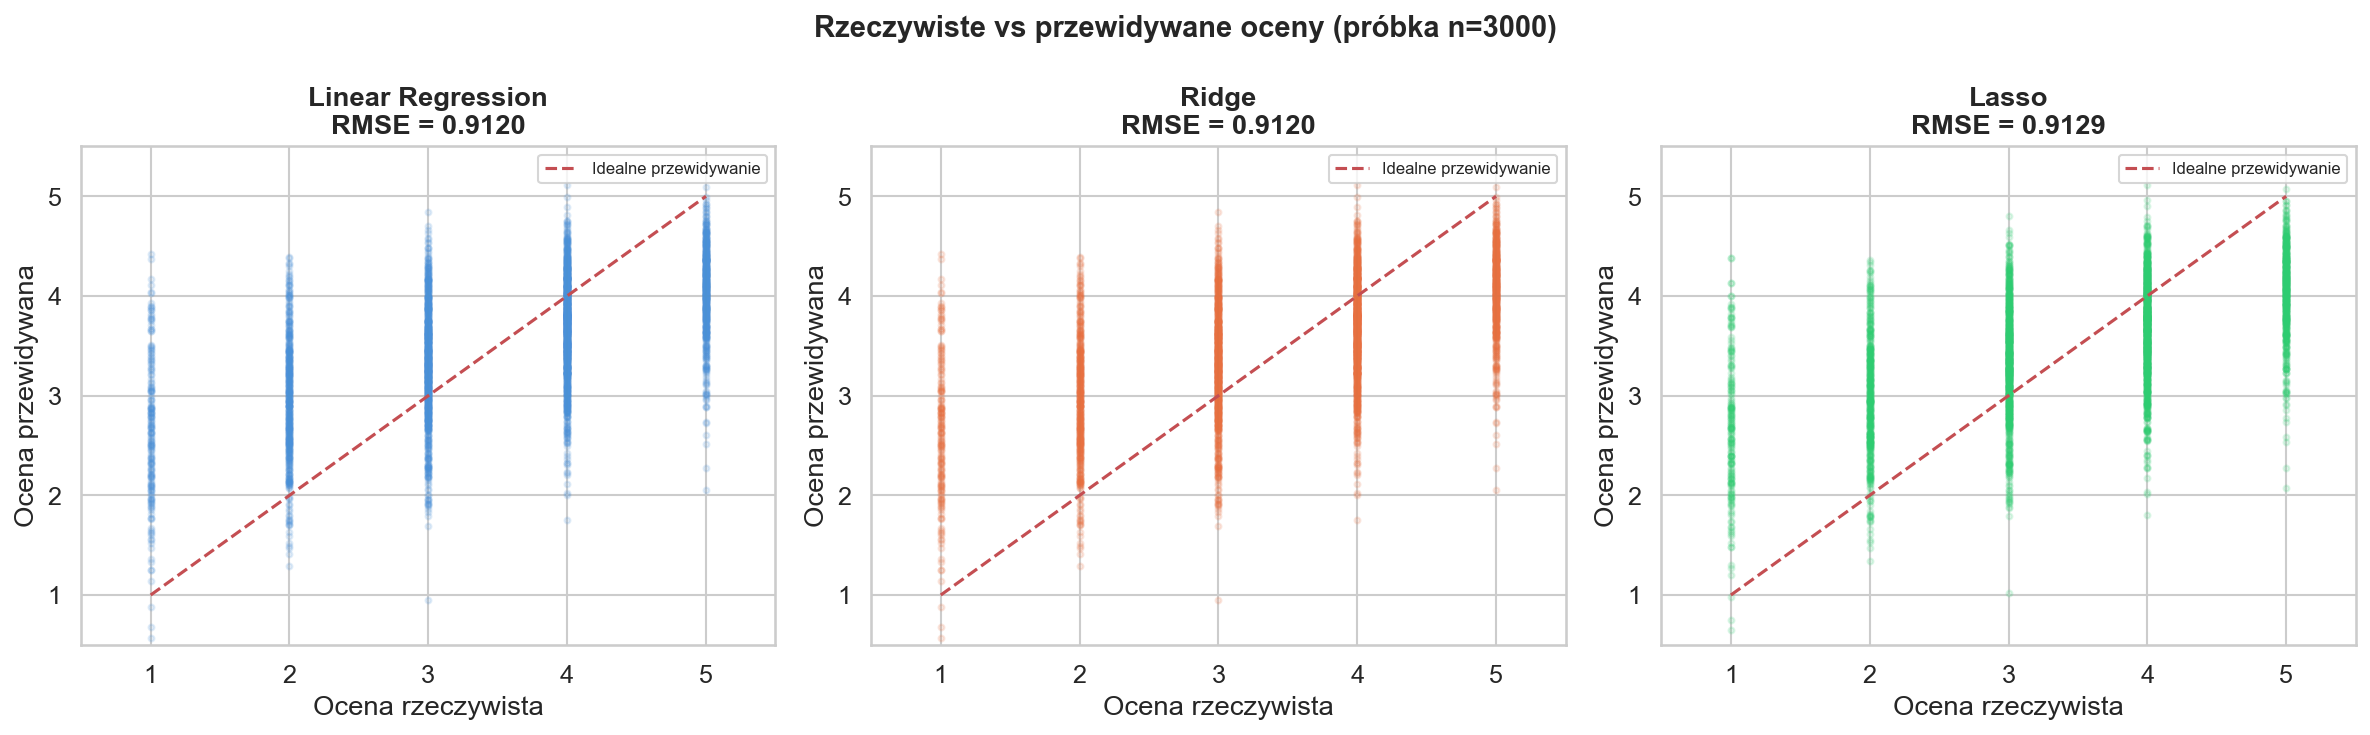

Zapisano: fig2_predicted_vs_actual.png


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sample = np.random.RandomState(42).choice(len(y_test), 3000, replace=False)

for ax, preds, name, color in zip(
    axes,
    [y_pred_lr, y_pred_ridge, y_pred_lasso],
    ['Linear Regression', 'Ridge', 'Lasso'],
    ['#4a90d9', '#e87040', '#2ecc71']
):
    ax.scatter(y_test[sample], preds[sample],
               alpha=0.15, s=8, color=color)
    ax.plot([1, 5], [1, 5], 'r--', linewidth=1.5, label='Idealne przewidywanie')
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    ax.set_title(f'{name}\nRMSE = {rmse:.4f}', fontweight='bold')
    ax.set_xlabel('Ocena rzeczywista')
    ax.set_ylabel('Ocena przewidywana')
    ax.set_xlim(0.5, 5.5)
    ax.set_ylim(0.5, 5.5)
    ax.legend(fontsize=8)

plt.suptitle('Rzeczywiste vs przewidywane oceny (próbka n=3000)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('notebooks/fig2_predicted_vs_actual.png')
plt.show()
print("Zapisano: fig2_predicted_vs_actual.png")

## Wykres 3 — Analiza reszt

Histogram reszt i wykres reszt vs wartości przewidywane
dla modelu regresji liniowej.

Idealny model: histogram symetryczny względem zera,
brak wzorców na wykresie prawym.

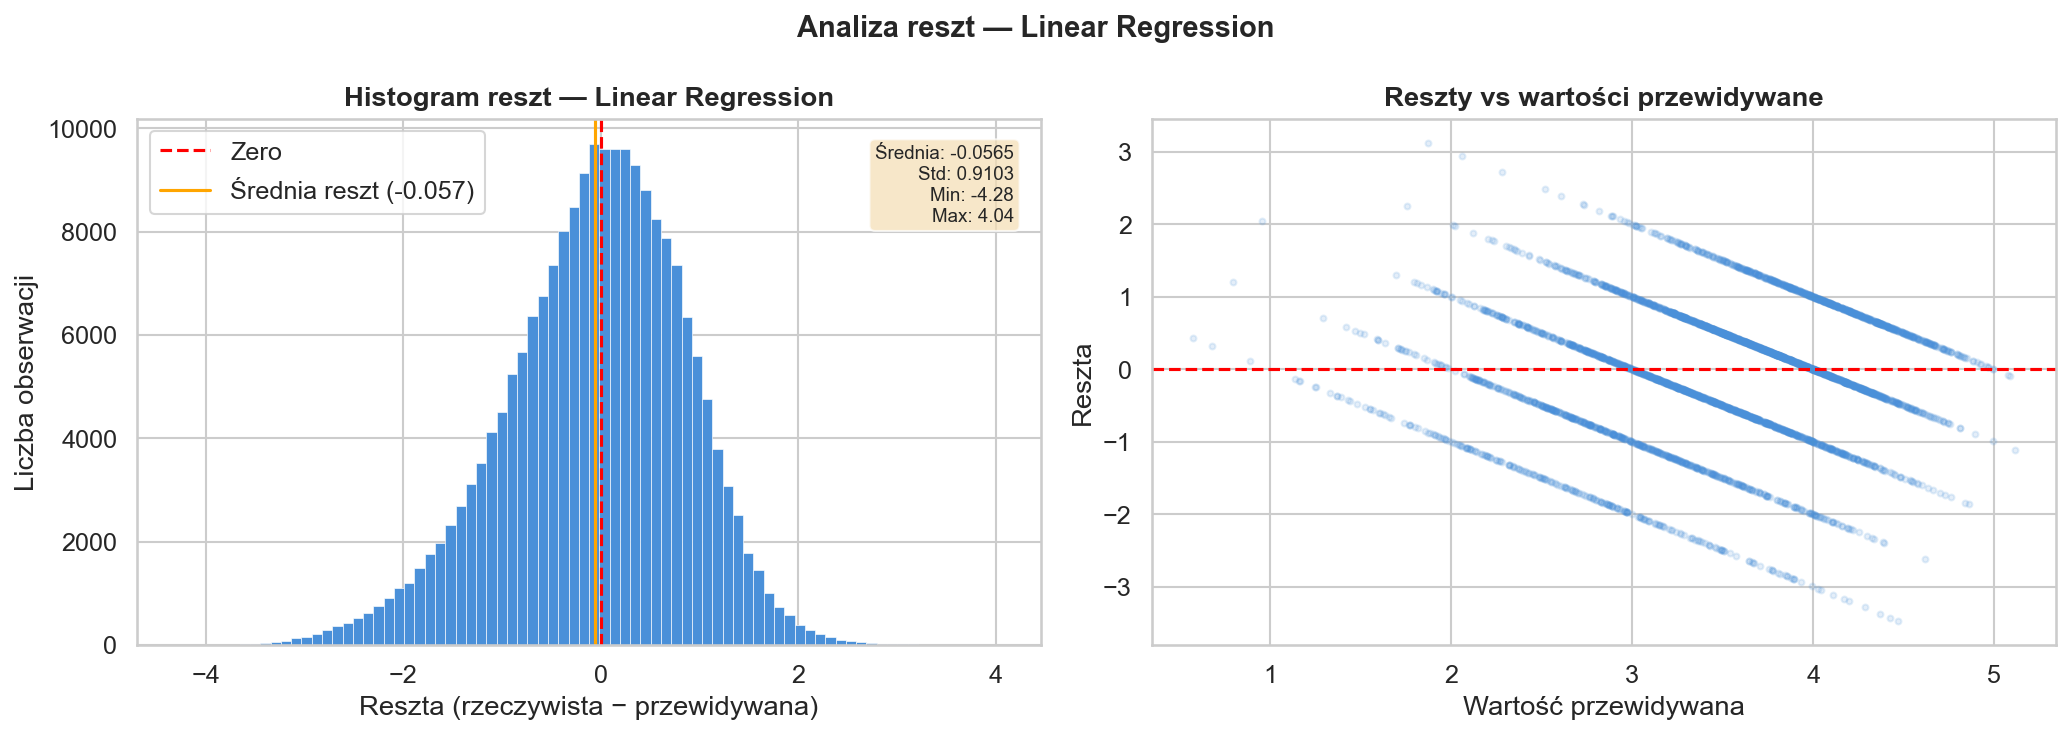

Zapisano: fig3_residuals.png


In [4]:
residuals = y_test - y_pred_lr
sample    = np.random.RandomState(42).choice(len(y_test), 4000, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram reszt
axes[0].hist(residuals, bins=80, color='#4a90d9',
             edgecolor='white', linewidth=0.3)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero')
axes[0].axvline(residuals.mean(), color='orange', linestyle='-',
                linewidth=1.5, label=f'Średnia reszt ({residuals.mean():.3f})')
axes[0].set_title('Histogram reszt — Linear Regression', fontweight='bold')
axes[0].set_xlabel('Reszta (rzeczywista − przewidywana)')
axes[0].set_ylabel('Liczba obserwacji')
axes[0].legend()

stats_text = (f'Średnia: {residuals.mean():.4f}\n'
              f'Std: {residuals.std():.4f}\n'
              f'Min: {residuals.min():.2f}\n'
              f'Max: {residuals.max():.2f}')
axes[0].text(0.97, 0.95, stats_text, transform=axes[0].transAxes,
             verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7),
             fontsize=9)

# reszty vs przewidywane
axes[1].scatter(y_pred_lr[sample], residuals[sample],
                alpha=0.15, s=8, color='#4a90d9')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Reszty vs wartości przewidywane', fontweight='bold')
axes[1].set_xlabel('Wartość przewidywana')
axes[1].set_ylabel('Reszta')

plt.suptitle('Analiza reszt — Linear Regression',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('notebooks/fig3_residuals.png')
plt.show()
print("Zapisano: fig3_residuals.png")

## Wykres 4 — Współczynniki regresji

Top 20 cech o największym wpływie na przewidywaną ocenę.

Niebieski = cecha zwiększa ocenę.
Koralowy = cecha zmniejsza ocenę.
Długość słupka = siła wpływu.

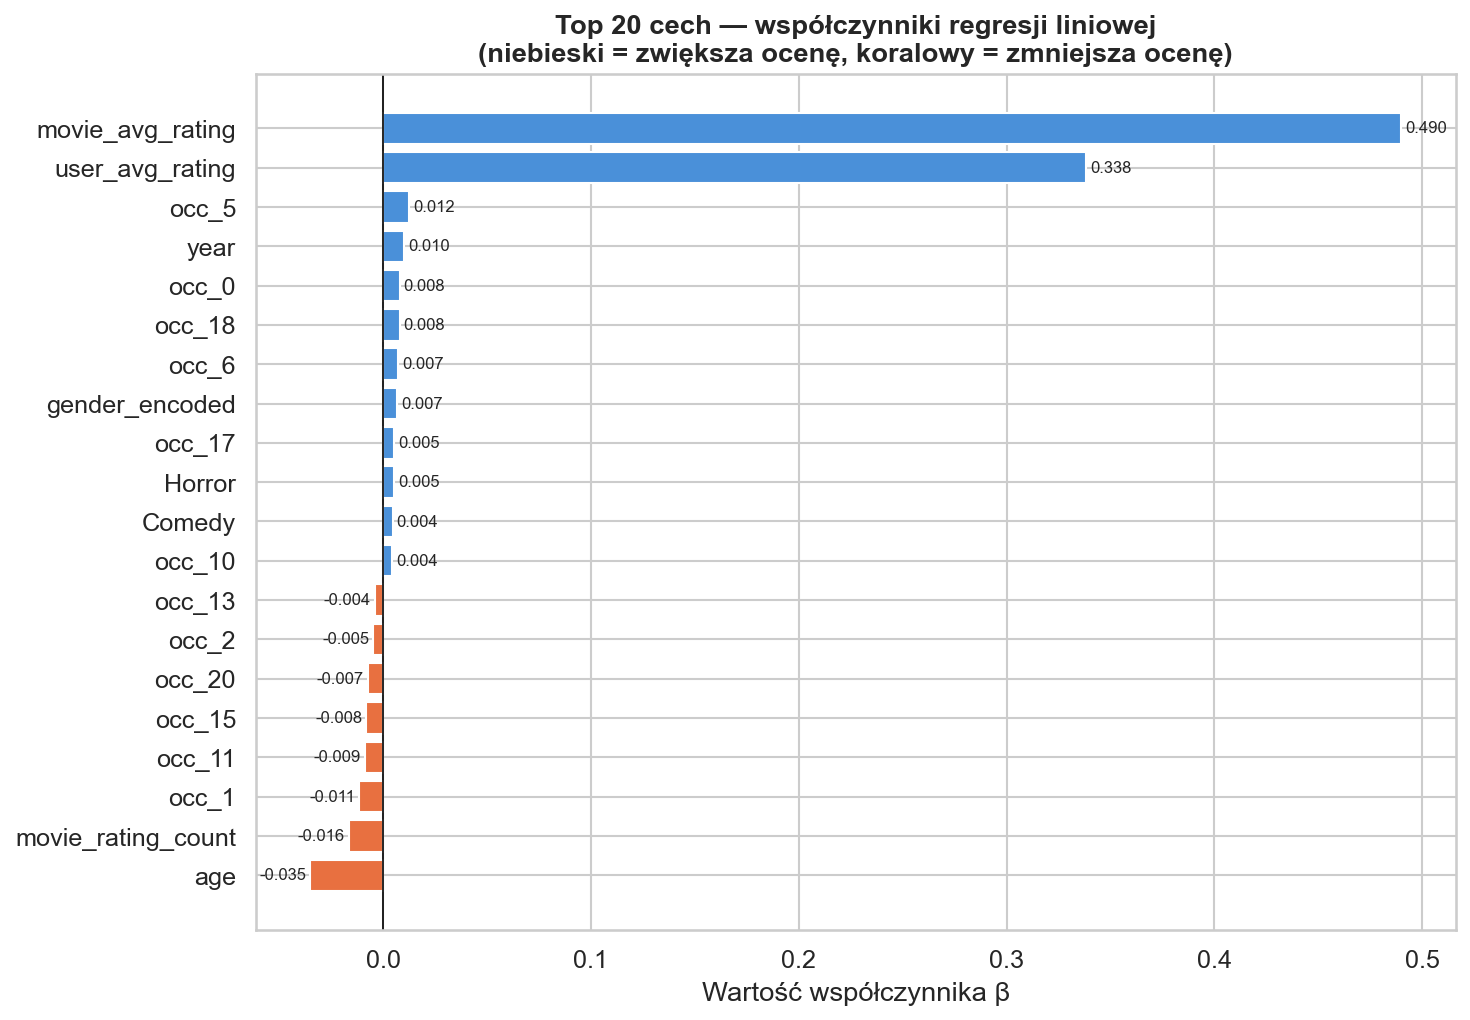

Zapisano: fig4_coefficients.png


In [5]:
coef_df = pd.DataFrame({
    'feature':     FEATURE_COLS,
    'coefficient': lr.coef_
})
coef_df['abs'] = coef_df['coefficient'].abs()
coef_df = coef_df.nlargest(20, 'abs').sort_values('coefficient')

colors = ['#e87040' if c < 0 else '#4a90d9' for c in coef_df['coefficient']]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(coef_df['feature'], coef_df['coefficient'],
               color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)

for bar, val in zip(bars, coef_df['coefficient']):
    ax.text(val + (0.002 if val >= 0 else -0.002),
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}',
            va='center',
            ha='left' if val >= 0 else 'right',
            fontsize=8)

ax.set_title('Top 20 cech — współczynniki regresji liniowej\n'
             '(niebieski = zwiększa ocenę, koralowy = zmniejsza ocenę)',
             fontweight='bold')
ax.set_xlabel('Wartość współczynnika β')
plt.tight_layout()
plt.savefig('notebooks/fig4_coefficients.png')
plt.show()
print("Zapisano: fig4_coefficients.png")

## Wykres 5 — Krzywa ROC (regresja logistyczna)

Krzywa ROC pokazuje zdolność modelu logistycznego do rozróżniania
między klasami "polubi" i "nie polubi" przy różnych progach decyzyjnych.

AUC = pole pod krzywą. Im bliżej 1.0, tym lepszy model.
Czerwona linia przerywana = model losowy (AUC = 0.5).

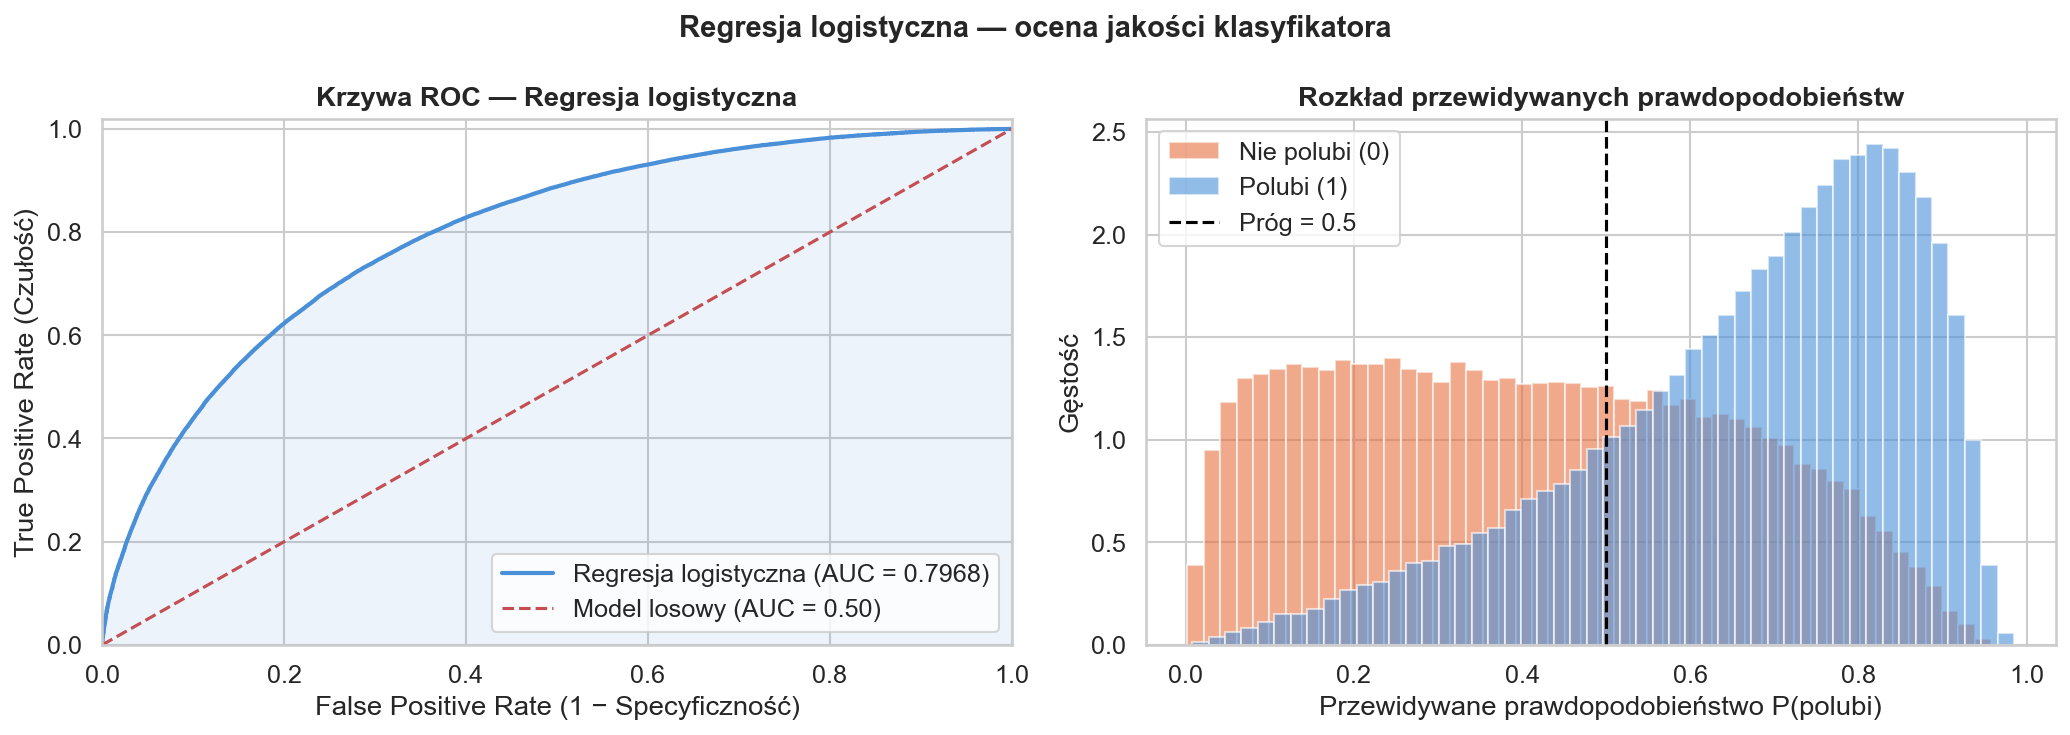

AUC-ROC: 0.7968
Zapisano: fig5_roc_curve.png


In [6]:
fpr, tpr, thresholds = roc_curve(y_test_binary, y_pred_log_proba)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# krzywa ROC
axes[0].plot(fpr, tpr, color='#4a90d9', linewidth=2,
             label=f'Regresja logistyczna (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='Model losowy (AUC = 0.50)')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#4a90d9')
axes[0].set_title('Krzywa ROC — Regresja logistyczna', fontweight='bold')
axes[0].set_xlabel('False Positive Rate (1 − Specyficzność)')
axes[0].set_ylabel('True Positive Rate (Czułość)')
axes[0].legend(loc='lower right')
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.02])

# rozkład prawdopodobieństw
axes[1].hist(y_pred_log_proba[y_test_binary == 0], bins=50,
             alpha=0.6, color='#e87040', label='Nie polubi (0)', density=True)
axes[1].hist(y_pred_log_proba[y_test_binary == 1], bins=50,
             alpha=0.6, color='#4a90d9', label='Polubi (1)', density=True)
axes[1].axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Próg = 0.5')
axes[1].set_title('Rozkład przewidywanych prawdopodobieństw', fontweight='bold')
axes[1].set_xlabel('Przewidywane prawdopodobieństwo P(polubi)')
axes[1].set_ylabel('Gęstość')
axes[1].legend()

plt.suptitle('Regresja logistyczna — ocena jakości klasyfikatora',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('notebooks/fig5_roc_curve.png')
plt.show()
print(f"AUC-ROC: {roc_auc:.4f}")
print("Zapisano: fig5_roc_curve.png")

## Wykres 6 — Macierz korelacji kluczowych cech

Macierz korelacji pokazuje zależności między najważniejszymi
zmiennymi numerycznymi modelu.

Wartości bliskie +1 = silna korelacja dodatnia.
Wartości bliskie -1 = silna korelacja ujemna.
Wartości bliskie 0 = brak liniowej zależności.

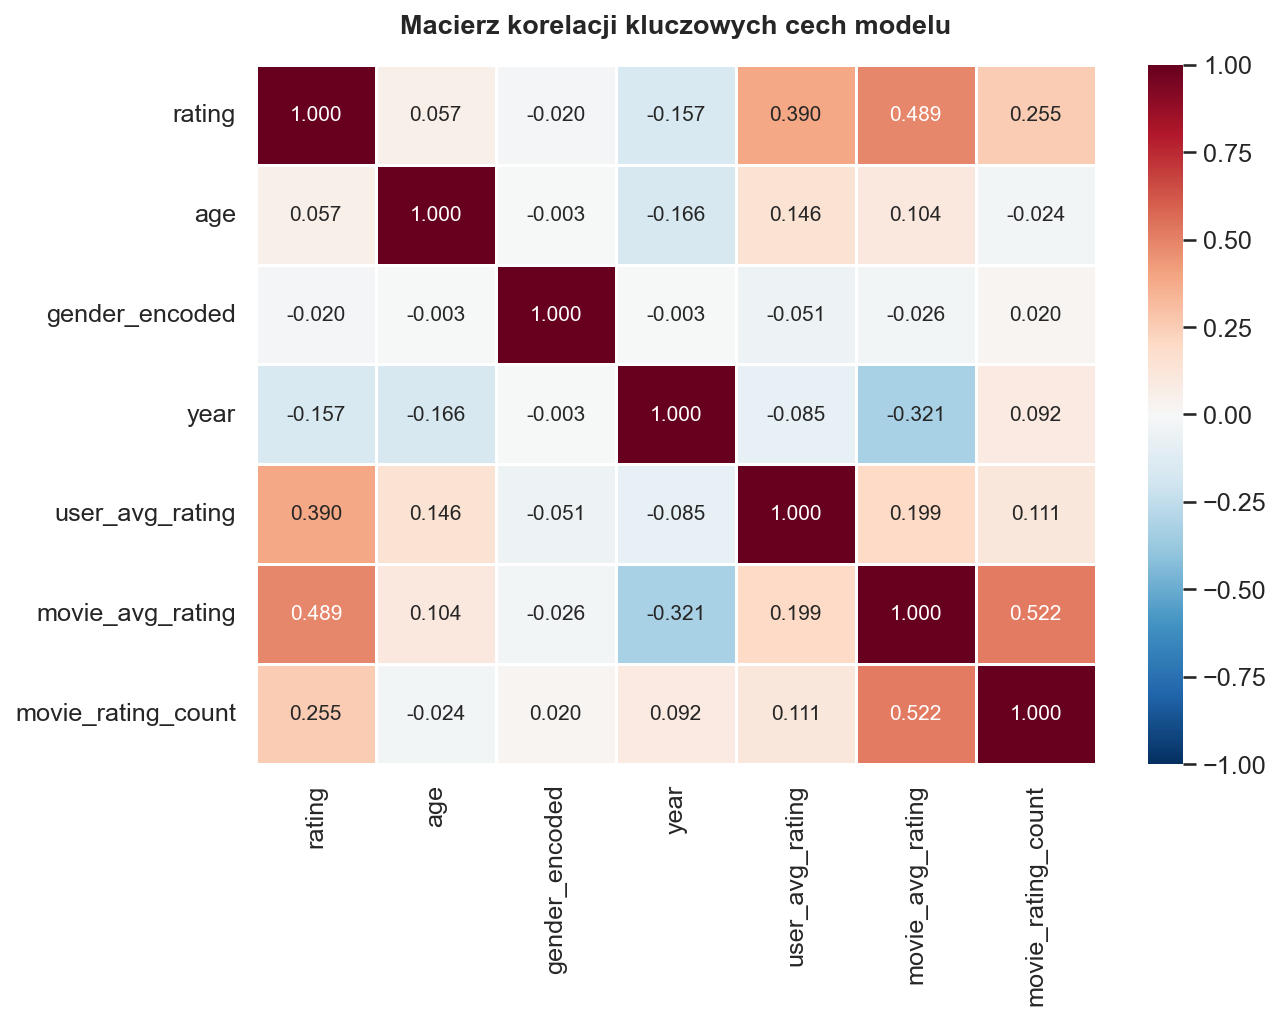

Zapisano: fig6_correlation_matrix.png


In [7]:
df_model = pd.read_csv('data/df_model.csv')

key_cols = ['rating', 'age', 'gender_encoded', 'year',
            'user_avg_rating', 'movie_avg_rating', 'movie_rating_count']
key_cols = [c for c in key_cols if c in df_model.columns]

corr = df_model[key_cols].corr().round(3)

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True

sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax,
            annot_kws={'size': 10})

ax.set_title('Macierz korelacji kluczowych cech modelu',
             fontweight='bold', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('notebooks/fig6_correlation_matrix.png')
plt.show()
print("Zapisano: fig6_correlation_matrix.png")

## Podsumowanie — lista wygenerowanych wykresów

Wszystkie wykresy są gotowe do wklejenia w pracę magisterską.

In [8]:
import glob

figures = sorted(glob.glob('notebooks/fig*.png'))
print("Wygenerowane wykresy:")
for f in figures:
    print(f"  ✓ {f}")
print(f"\nŁącznie: {len(figures)} wykresów")

Wygenerowane wykresy:
  ✓ notebooks/fig1_model_comparison.png
  ✓ notebooks/fig2_predicted_vs_actual.png
  ✓ notebooks/fig3_residuals.png
  ✓ notebooks/fig4_coefficients.png
  ✓ notebooks/fig5_roc_curve.png
  ✓ notebooks/fig6_correlation_matrix.png
  ✓ notebooks/fig_group_activity.png
  ✓ notebooks/fig_group_age.png
  ✓ notebooks/fig_group_gender.png
  ✓ notebooks/fig_group_occupation.png

Łącznie: 10 wykresów
